# Chagas Drug Discovery | Modelo 1 - Classificacao Inibidor vs Decoy
**Alvo:** Cruzipain (Cruzain) | CHEMBL3563 | *Trypanosoma cruzi*  
**Objetivo:** Treinar um classificador binario capaz de distinguir inibidores de Cruzipain de moleculas decoy (inativas).

**Pipeline:** carregamento -> alinhamento de features -> capping IQR -> KNN Imputer -> treino (LR, DT, RF) -> avaliacao -> selecao de features -> analise estatistica.

## 0. Imports e carregamento dos dados
Carrega os inibidores ja prunados (628 features) e os decoys completos. O alinhamento de colunas e feito na proxima celula.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc,
                              ConfusionMatrixDisplay)
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')
import joblib
from sklearn.model_selection import StratifiedKFold
import os
from scipy.stats import mannwhitneyu

df_inh = pd.read_csv(r'..\data\processed\inhibitors_pruned.csv')
df_dec = pd.read_csv(r'..\data\processed\decoys_full.csv')

print(f"Inibidores: {df_inh.shape}")
print(f"Decoys:     {df_dec.shape}")

Inibidores: (508, 631)
Decoys:     (600, 1876)


## 1. Separacao de metadados e alinhamento de features
Remove as colunas de metadados (`smiles`, `IC50_nM`, `potency_class`) e alinha os decoys para usarem exatamente as mesmas 628 features selecionadas no pruning dos inibidores.

In [2]:
META_INH = ['smiles', 'IC50_nM', 'potency_class']
META_DEC = ['smiles']

df_inh_desc = df_inh.drop(columns=META_INH)
df_dec_desc = df_dec.drop(columns=META_DEC)

selected_features = joblib.load(r'..\models\selected_features.pkl')
df_dec_desc = df_dec_desc[selected_features]

print(f"Descritores inibidores: {df_inh_desc.shape}")
print(f"Descritores decoys:     {df_dec_desc.shape}")

Descritores inibidores: (508, 628)
Descritores decoys:     (600, 628)


## 2. Capping de outliers via IQR
Limita valores extremos ao intervalo [Q1 - 1.5xIQR, Q3 + 1.5xIQR] para que o KNN Imputer nao seja distorcido por outliers. 

In [3]:
def iqr_capping(df):
    df = df.copy()
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper = Q3 + 1.5 * IQR
        lower = Q1 - 1.5 * IQR
        df[col] = np.clip(df[col], lower, upper)
    return df

df_inh_capped = iqr_capping(df_inh_desc)
df_dec_capped = iqr_capping(df_dec_desc)
print("Capping concluido.")

Capping concluido.


## 3. KNN Imputer (n_neighbors=7)
Imputa valores faltantes usando os 7 vizinhos mais proximos. O imputer e treinado nos inibidores (`fit_transform`) e aplicado nos decoys (`transform`), evitando vazamento de informacao entre os conjuntos.

O imputer treinado e salvo mais adiante para reuso na predicao de moleculas novas no Streamlit.

In [4]:
imputer = KNNImputer(n_neighbors=7)

df_inh_imp = pd.DataFrame(
    imputer.fit_transform(df_inh_capped),
    columns=df_inh_capped.columns
)

df_dec_imp = pd.DataFrame(
    imputer.transform(df_dec_capped),
    columns=df_dec_capped.columns
)

print(f"Nulos após imputer nos inibidores: {df_inh_imp.isnull().sum().sum()}")
print(f"Nulos após imputer nos decoys: {df_dec_imp.isnull().sum().sum()}")

Nulos após imputer nos inibidores: 0
Nulos após imputer nos decoys: 0


## 4. Atribuicao de labels e concatenacao
Atribui o rotulo D/I (1 = inibidor | 0 = decoy) e concatena os dois conjuntos em um unico dataset de classificacao.

In [5]:
common_cols = df_inh_imp.columns.tolist()
df_dec_aligned = df_dec_imp[common_cols]

df_inh_imp['D/I'] = 1
df_dec_aligned = df_dec_aligned.copy()
df_dec_aligned['D/I'] = 0

df_classification = pd.concat([df_inh_imp, df_dec_aligned], axis=0, ignore_index=True)

print(f"Dataset classificacao: {df_classification.shape}")
print(df_classification['D/I'].value_counts())

Dataset classificacao: (1108, 629)
D/I
0    600
1    508
Name: count, dtype: int64


## 5. Verificacao do alinhamento de colunas
Confirma que inibidores e decoys compartilham as mesmas 628 features. A unica coluna extra nos inibidores e o proprio rotulo `D/I`.

In [6]:
print(f"Colunas inibidores: {df_inh_imp.shape[1]}")
print(f"Colunas decoys:     {df_dec_imp.shape[1]}")
print(f"Colunas em comum:   {len(set(df_inh_imp.columns) & set(df_dec_imp.columns))}")
print(f"Só nos inibidores:  {len(set(df_inh_imp.columns) - set(df_dec_imp.columns))}")
print(f"Só nos decoys:      {len(set(df_dec_imp.columns) - set(df_inh_imp.columns))}")

Colunas inibidores: 629
Colunas decoys:     628
Colunas em comum:   628
Só nos inibidores:  1
Só nos decoys:      0


## 6. Treinamento dos tres modelos
Split estratificado 80/20 e treino de Logistic Regression, Decision Tree e Random Forest.

**Resultados obtidos:**

| Modelo | Acuracia |
|---|---|
| Random Forest | 99.1% |
| Decision Tree | 97.8% |
| Logistic Regression | 89.6% |

In [7]:
x = df_classification.drop('D/I', axis=1)
y = df_classification['D/I']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

rf   = RandomForestClassifier(random_state=42)
clf3 = DecisionTreeClassifier(random_state=42)
lr   = LogisticRegression(max_iter=1000, random_state=42)

rf.fit(x_train, y_train)
clf3.fit(x_train, y_train)
lr.fit(x_train, y_train)

y_pred  = rf.predict(x_test)
y_pred3 = clf3.predict(x_test)
y_pred2 = lr.predict(x_test)

print(f"RF:  {accuracy_score(y_test, y_pred):.4f}")
print(f"DT:  {accuracy_score(y_test, y_pred3):.4f}")
print(f"LR:  {accuracy_score(y_test, y_pred2):.4f}")

RF:  0.9910
DT:  0.9775
LR:  0.8964


## 7. Metricas comparativas e cross-validation
Calcula accuracy, precision, recall e F1 para os tres modelos, alem de validacao cruzada de 10 folds.

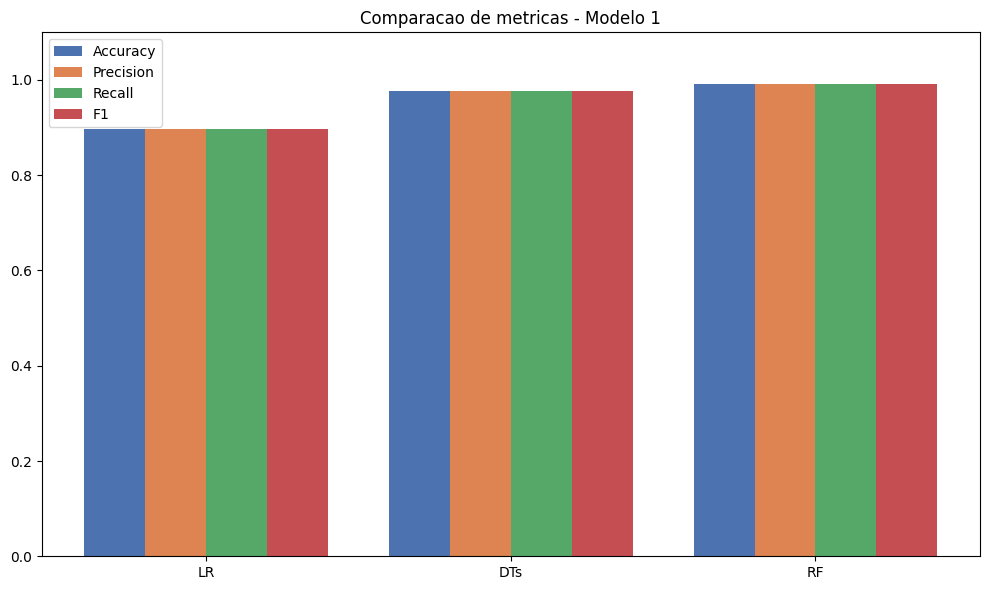

In [8]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
x_class = df_classification.drop('D/I', axis=1)
y_class  = df_classification['D/I']

models_list  = ['LR', 'DTs', 'RF']
classifiers  = [lr, clf3, rf]
y_preds      = [y_pred2, y_pred3, y_pred]
colors       = ['#2E8B57', '#fc8d62', '#8da0cb']

accuracies, precisions, recalls, f1s, cv_means, cv_stds = [], [], [], [], [], []

for clf, yp in zip(classifiers, y_preds):
    accuracies.append(accuracy_score(y_test, yp))
    precisions.append(precision_score(y_test, yp, average='weighted'))
    recalls.append(recall_score(y_test, yp, average='weighted'))
    f1s.append(f1_score(y_test, yp, average='weighted'))
    cv_sc = cross_val_score(clf, x_class, y_class, cv=cv, scoring='accuracy')
    cv_means.append(cv_sc.mean())
    cv_stds.append(cv_sc.std())

x_pos = np.arange(len(models_list))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x_pos - 1.5*width, accuracies, width, label='Accuracy',  color='#4C72B0')
ax.bar(x_pos - 0.5*width, precisions, width, label='Precision', color='#DD8452')
ax.bar(x_pos + 0.5*width, recalls,    width, label='Recall',    color='#55A868')
ax.bar(x_pos + 1.5*width, f1s,        width, label='F1',        color='#C44E52')
ax.set_xticks(x_pos)
ax.set_xticklabels(models_list)
ax.set_ylim(0, 1.1)
ax.legend()
ax.set_title('Comparacao de metricas - Modelo 1')
plt.tight_layout()
plt.savefig(r'..\data\figures\model1_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Curvas ROC e matrizes de confusao
As curvas ROC mostram a capacidade de discriminacao de cada modelo (quanto mais proximo de AUC = 1, melhor). As matrizes de confusao detalham acertos e erros por classe.

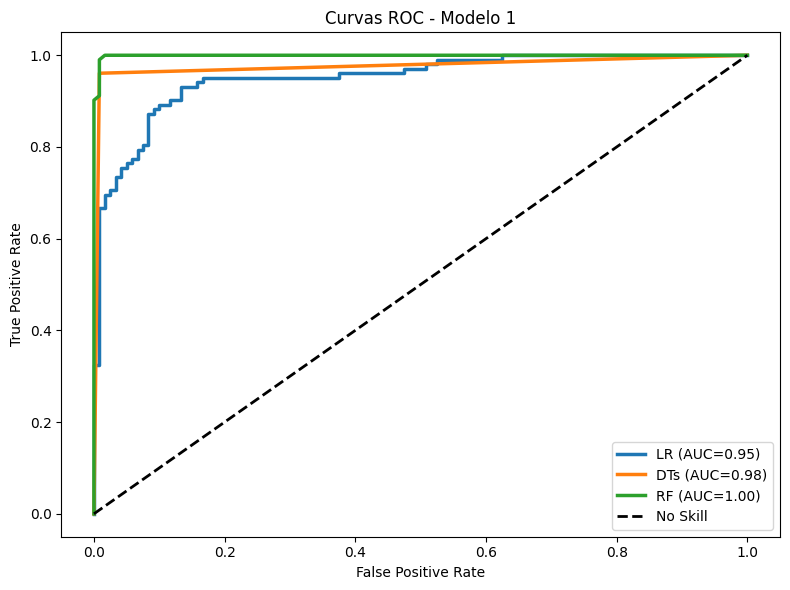

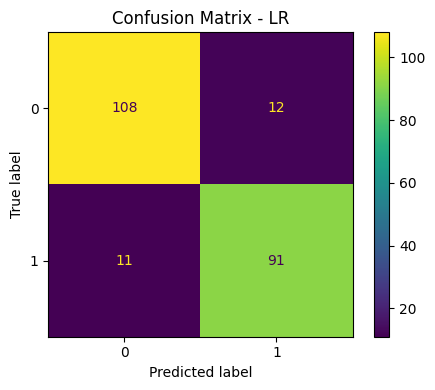

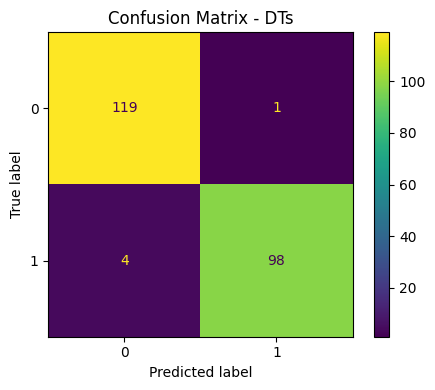

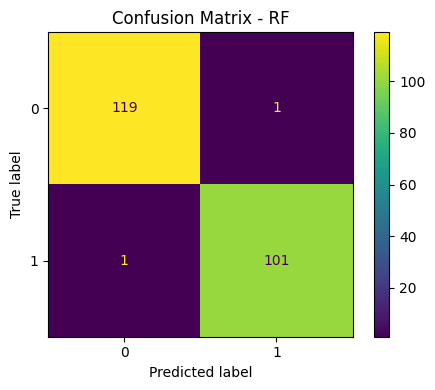

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
for clf, name, yp in zip(classifiers, models_list, y_preds):
    proba = clf.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC={roc_auc:.2f})')
ax.plot([0,1],[0,1],'k--', linewidth=2, label='No Skill')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC - Modelo 1')
ax.legend()
plt.tight_layout()
plt.savefig(r'..\data\figures\model1_roc.png', dpi=150, bbox_inches='tight')
plt.show()

for yp, name in zip(y_preds, models_list):
    cm = confusion_matrix(y_test, yp)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(cmap='viridis', ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.savefig(f'../data/figures/model1_cm_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Selecao de features - curva de plato
Treina um Random Forest para extrair a importancia de cada descritor e testa a acuracia acumulada conforme adiciona os top N descritores. A acuracia estabiliza (plato) com poucas features, confirmando que um subconjunto compacto e suficiente.

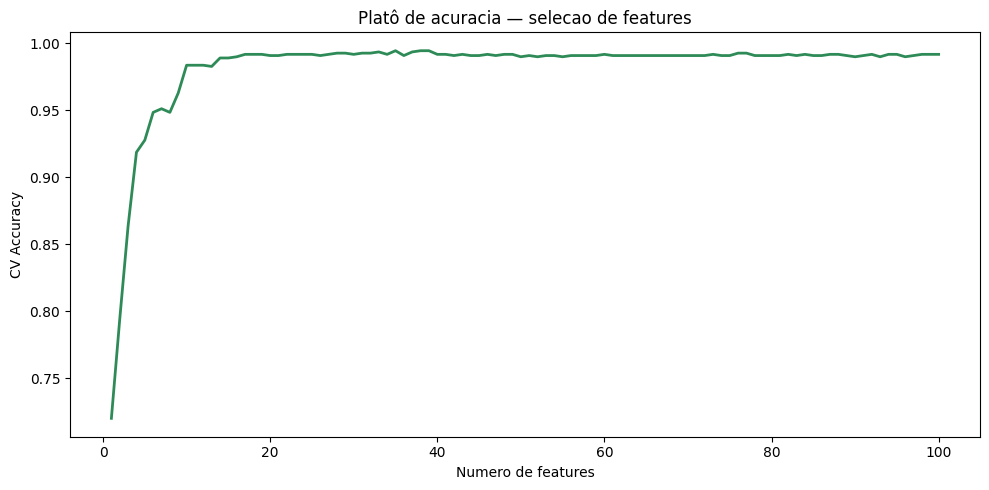

Top 26 features:
       Feature  Importance
0      minsCH3    0.051234
1      MDEN-12    0.040498
2    minHCsats    0.032665
3    maxHCsats    0.029983
4    maxHBint7    0.027148
5    minHBint8    0.022441
6        SaaaC    0.021904
7    minHBint7    0.021495
8   SpMax1_Bhm    0.021080
9      maxdssC    0.021014
10     SHBint7    0.020294
11        ndsN    0.019821
12    maxsssCH    0.019107
13    BCUTw-1l    0.019069
14      mindsN    0.018746
15       SdssC    0.018550
16    minHdsCH    0.016738
17       nsssN    0.015833
18     minaaaC    0.014059
19     SHBint3    0.012944
20     nHBint9    0.012942
21     minssNH    0.012340
22     minsssN    0.012329
23     mindsCH    0.010980
24       naaaC    0.010596
25     SHBint8    0.010224


In [10]:
rf_imp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_imp.fit(x_class, y_class)

importances = rf_imp.feature_importances_
df_imp = pd.DataFrame({'Feature': x_class.columns, 'Importance': importances})
df_imp = df_imp.sort_values('Importance', ascending=False).reset_index(drop=True)

cv_accs = []
for n in range(1, min(101, len(df_imp)+1)):
    top_feats = df_imp.iloc[:n]['Feature'].tolist()
    score = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        x_class[top_feats], y_class, cv=5, scoring='accuracy'
    ).mean()
    cv_accs.append(score)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cv_accs)+1), cv_accs, color='#2E8B57', linewidth=2)
plt.xlabel('Numero de features')
plt.ylabel('CV Accuracy')
plt.title('Platô de acuracia — selecao de features')
plt.tight_layout()
plt.savefig(r'..\data\figures\model1_plateau.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 26 features:")
print(df_imp.head(26).to_string())

## 10. Persistencia dos modelos
Salva os arquivos que serao carregados pelo Streamlit.
- `decoy_inhibitor_rf.pkl` - modelo Random Forest (melhor desempenho)
- `imputer_model.pkl` - KNN Imputer treinado
- `top_features_model1.pkl` - lista dos top descritores

In [ ]:
os.makedirs('../models', exist_ok=True)

# Modelo 1 — Random Forest (melhor desempenho)
with open(r'..\models\decoy_inhibitor_rf.pkl', 'wb') as f:
    pickle.dump(rf, f)

# KNN Imputer treinado
with open(r'..\models\imputer_model.pkl', 'wb') as f:
    pickle.dump(imputer, f)

# Top 26 features )
top_features = df_imp.head(26)['Feature'].tolist()
with open(r'..\models\top_features_model1.pkl', 'wb') as f:
    pickle.dump(top_features, f)

# Salvar também em CSV para consulta
df_imp.head(26).to_csv(r'..\data\figures\model1_top_features.csv', index=False)

print(f"Modelos salvos em ../models/")
print(f"Top 26 features salvas.")

Modelos salvos em ../models/
Top 26 features salvas.


## 11. Analise estatistica - Mann-Whitney
Compara a distribuicao de cada top descritor entre decoys e inibidores usando o teste U de Mann-Whitney. Um p-value baixo (< 0.05) confirma que o descritor separa significativamente as duas classes.


In [12]:

# Usar o dataset de classificação com label D/I
df_stats = df_classification.copy()

stats = []
for feature in top_features:
    decoy_vals = df_stats[df_stats['D/I'] == 0][feature]
    inhib_vals = df_stats[df_stats['D/I'] == 1][feature]

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(decoy_vals, inhib_vals, alternative='two-sided')

    stats.append({
        'Descriptor': feature,
        'Decoy (Mean±SD)':     f"{decoy_vals.mean():.2f} ± {decoy_vals.std():.2f}",
        'Inhibitor (Mean±SD)': f"{inhib_vals.mean():.2f} ± {inhib_vals.std():.2f}",
        'p-value': f"{p_value:.2e}"
    })

stats_df = pd.DataFrame(stats)
stats_df.to_csv(r'..\data\figures\model1_feature_stats.csv', index=False)
print(stats_df.to_string(index=False))

Descriptor Decoy (Mean±SD) Inhibitor (Mean±SD)  p-value
   minsCH3     1.68 ± 0.52         1.01 ± 0.90 4.32e-36
   MDEN-12     0.00 ± 0.01         0.31 ± 0.42 1.05e-64
 minHCsats     0.32 ± 0.18         0.28 ± 0.24 3.23e-03
 maxHCsats     0.56 ± 0.23         0.48 ± 0.40 6.47e-05
 maxHBint7     0.49 ± 0.82         1.71 ± 2.50 1.65e-11
 minHBint8     0.06 ± 0.12         0.24 ± 0.39 9.28e-11
     SaaaC     0.00 ± 0.02         0.50 ± 0.84 5.19e-42
 minHBint7     0.20 ± 0.41         0.88 ± 1.29 1.25e-14
SpMax1_Bhm     4.12 ± 0.27         4.19 ± 0.34 8.99e-05
   maxdssC     0.08 ± 0.13         0.31 ± 0.45 1.35e-09
   SHBint7     0.48 ± 0.87         2.02 ± 3.01 1.30e-12
      ndsN     0.00 ± 0.02         0.49 ± 0.73 5.05e-55
  maxsssCH     0.26 ± 0.34         0.03 ± 0.05 1.25e-26
  BCUTw-1l    11.96 ± 0.06        11.92 ± 0.07 6.63e-29
    mindsN     0.00 ± 0.06         1.43 ± 2.00 3.64e-54
     SdssC    -0.10 ± 0.36        -0.04 ± 1.15 1.31e-01
  minHdsCH     0.00 ± 0.01         0.16 ± 0.26 7

## 12. Violin plots dos top descritores
Visualiza a separacao das distribuicoes entre decoy e inibidor para os 6 descritores mais importantes. Descritores ligados a interacoes de ligacao de hidrogenio (como MDEN-12 e maxHBint7) mostram separacao clara, confirmando que o modelo aprende padroes quimicos reais - nao apenas memoriza os dados.

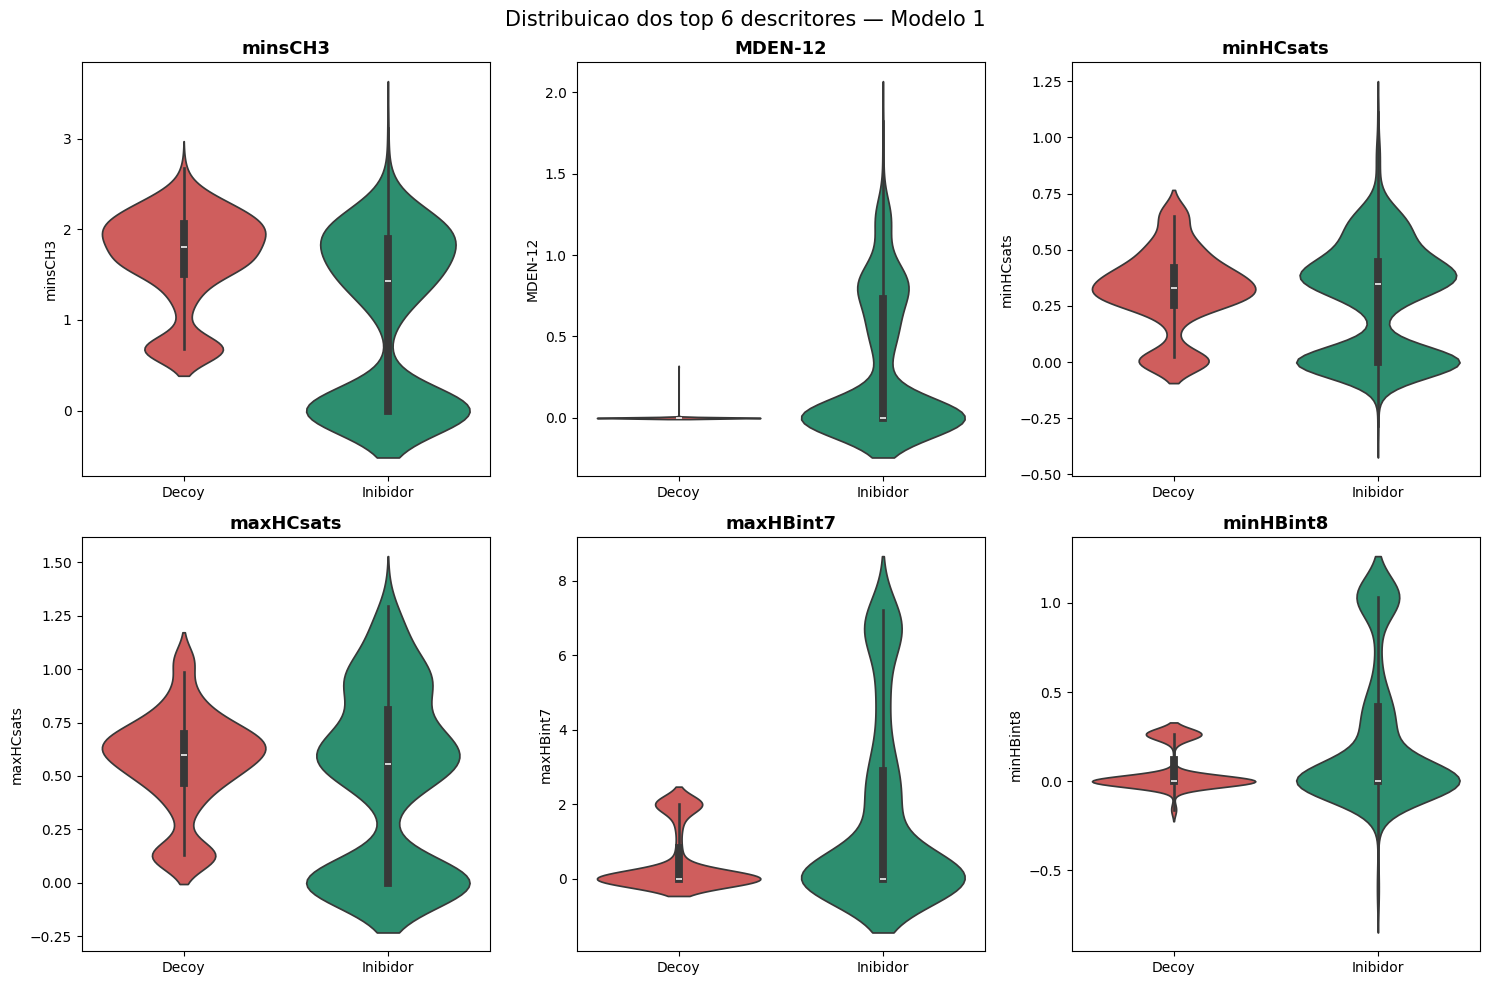

In [13]:
# Plotar os top 6 descritores em um grid
top_6 = top_features[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_6):
    sns.violinplot(data=df_classification, x='D/I', y=feature,
                   palette=['#E24B4A', '#1D9E75'], ax=axes[i])
    axes[i].set_xticklabels(['Decoy', 'Inibidor'])
    axes[i].set_xlabel('')
    axes[i].set_title(feature, fontsize=13, fontweight='bold')

plt.suptitle('Distribuicao dos top 6 descritores — Modelo 1', fontsize=15)
plt.tight_layout()
plt.savefig(r'..\data\figures\model1_violins.png', dpi=150, bbox_inches='tight')
plt.show()

## Resultados do Modelo 1 | Inibidor-Decoy

**Desempenho dos modelos:**
- Random Forest: 99.1% 
- Decision Tree:  97.8%
- Logistic Regression: 89.6%

**Feature selection:**
- 628 descritores apos pruning
- Acuracia estabiliza com ~26 descritores (curva de plato)
- Top descritores confirmados estatisticamente 

**Arquivos salvos:**
- models/decoy_inhibitor_rf.pkl 
- models/imputer_model.pkl 
- models/top_features_model1.pkl 